# Traffic-Aware Distribution Center Location for Last-Mile Delivery in Istanbul

## Problem
We address the **Capacitated Facility Location Problem (CFLP)** for last-mile delivery: given
Istanbul's **890 neighborhoods**, decide **which** neighborhoods to open as distribution centers
(DCs) and **how** to assign each neighborhood's demand to an open DC, so that the total cost —
facility *opening cost* plus traffic-weighted *delivery cost* — is minimized.

### Objective
$$\min\ Z = \sum_{j} f_j\, y_j \;+\; \sum_{i}\sum_{j} w_i\, t_{ij}\, z_{ij},
\qquad f_j = \alpha\, \bar r_{d(j)} \sqrt{Q/Q_0}$$

subject to: each neighborhood served by exactly one DC ($\sum_j z_{ij}=1$), assignment only to
open DCs ($z_{ij}\le y_j$), and DC capacity ($\sum_i w_i z_{ij}\le Q\,y_j$), with $y_j,z_{ij}\in\{0,1\}$.

| Symbol | Meaning |
|--------|---------|
| $w_i$ | demand (population) of neighborhood $i$ |
| $t_{ij}$ | travel time $i\to j$ (hours), from real traffic data |
| $\bar r_{d(j)}$ | commercial rent (TL/m²) at candidate $j$ |
| $\alpha$ | opening-cost scaling parameter (tuned via search) |
| $Q,\ Q_0$ | DC capacity and reference capacity |
| $y_j,\ z_{ij}$ | binary: open DC / assignment |

### Notebook roadmap
1. **Data** — load 890 neighborhoods and real traffic-derived travel times
2. **Model & methods** — CFLP solvers (CBC exact, greedy) and parameter search
3. **Static results** — solver comparison, robustness, search convergence
4. **Pareto analysis** — trade-off curve and chosen operating point
5. **Interactive dashboard** — sliders for $\alpha$, $Q$, traffic scenario and demand uncertainty $\delta$

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import ipywidgets as widgets
from IPython.display import display, HTML

# Add project root to path
sys.path.insert(0, os.path.abspath('..'))
from model.cflp import solve_cflp

import warnings
warnings.filterwarnings('ignore')

# Modern Dark Theme Setup
sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#1e1e1e", "figure.facecolor": "#121212",
    "text.color": "white", "axes.labelcolor": "white",
    "xtick.color": "white", "ytick.color": "white",
    "grid.color": "#333333"
})
colors = sns.color_palette("husl", 8)

DATA_DIR = '../data/processed'
RESULTS_DIR = '../results'
OUTPUTS_DIR = '../outputs'
os.makedirs(f'{OUTPUTS_DIR}/figures', exist_ok=True)
os.makedirs(f'{OUTPUTS_DIR}/maps', exist_ok=True)

## 1. Data Preparation & Loading

All inputs are produced by `data/prepare_data.py` and stored in `data/processed/` (see `data/data.md`).

- **Neighborhoods (890):** centroid coordinates (IBB *Muhtarlık* GeoJSON) + population
  (TUİK 2025, total ≈ **14.9 M**) + commercial rent (Endeksa, neighborhood-level; mean ≈ **425 TL/m²**).
- **Travel-time matrices (890×890, hours):** `travel_times{,_peak,_offpeak}.npy`. Built from the IBB
  **Hourly Traffic Density** data set (Oct 2024): for every hour of the day we average the measured
  speed over **all days of the month** (a one-month *hourly* profile — not a single day), per geohash
  cell. Each neighborhood is mapped to its 3 nearest cells (**spatial mapping**). Peak = slowest 6 h
  (14–19), off-peak = fastest 6 h (0–5), blended = 24 h mean. O–D travel time =
  Haversine distance / harmonic-mean(endpoint speeds).

Below we load the processed data together with the pre-computed experiment results
(`results/*.csv`, `results/*.json`).

In [2]:
print("Loading data...")
df_n = pd.read_csv(f'{DATA_DIR}/neighborhoods.csv')
w = df_n['population'].values.astype(float)
r = df_n['rent_per_m2'].values.astype(float)
t_blended = np.load(f'{DATA_DIR}/travel_times.npy')
t_peak = np.load(f'{DATA_DIR}/travel_times_peak.npy')
t_offpeak = np.load(f'{DATA_DIR}/travel_times_offpeak.npy')

df_cbc_greedy = pd.read_csv(f'{RESULTS_DIR}/cbc_vs_greedy.csv')
df_rob = pd.read_csv(f'{RESULTS_DIR}/robustness.csv')

with open(f'{RESULTS_DIR}/search_1d_golden.json') as f: res_golden = json.load(f)
with open(f'{RESULTS_DIR}/search_1d_fibonacci.json') as f: res_fib = json.load(f)
with open(f'{RESULTS_DIR}/search_2d_nelder_mead.json') as f: res_nm = json.load(f)
with open(f'{RESULTS_DIR}/search_2d_grid.json') as f: res_grid = json.load(f)
print("Data loaded successfully!")

Loading data...
Data loaded successfully!


## 2. Optimization Model & Methods

**Inner problem — CFLP solvers** (`model/cflp.py`, shared `solve_cflp(...)` interface):
- **CBC (exact MILP)** via PuLP — solves the binary program to proven optimality on small/medium
  instances; used as the ground-truth baseline.
- **Greedy-add heuristic** — iteratively opens the DC with the largest marginal gain
  ($\text{savings} - f_j$) and re-assigns demand under capacity $Q$; scales to all 890 neighborhoods.

**Outer problem — parameter search** (`optimization/search.py`): tune $\alpha$ (and $Q$) by minimizing
the **knee-point loss** $L=\hat N+\hat S$ (normalized DC-count $+$ normalized service cost). Four
methods are compared — Golden-Section, Fibonacci (1D), Nelder–Mead and Grid Search (2D).

**Extended analysis:**
- **CBC vs. greedy** — solution quality and runtime across instance sizes (`experiments/cbc_vs_greedy.py`).
- **Robustness** — demand is perturbed $\tilde w_i = w_i\varepsilon_i,\ \varepsilon_i\sim U(1-\delta,1+\delta)$
  and solution stability is measured by the **Jaccard similarity** of the opened-DC set (`model/robustness.py`).

**Chosen operating point:** $\alpha = 1.37,\ Q = 200{,}000$ — the 1D-search optimum (Golden and Fibonacci
agree); used consistently in the figures, maps and the dashboard below.

## 3. Static Visualizations — Experimental Results

The 2×2 summary below reports the core experiments (at the chosen operating point $\alpha=1.37,\ Q=200{,}000$):
1. **CBC vs. greedy runtime** (log scale) — efficiency across instance sizes (20 → 890).
2. **Robustness** — Jaccard similarity of the opened-DC set as demand uncertainty $\delta$ grows (0.05 → 0.30).
3. **1D search convergence** — Golden-Section vs. Fibonacci on $L(\alpha)$.
4. **Nelder–Mead 2D search path** over $(\alpha, Q)$.

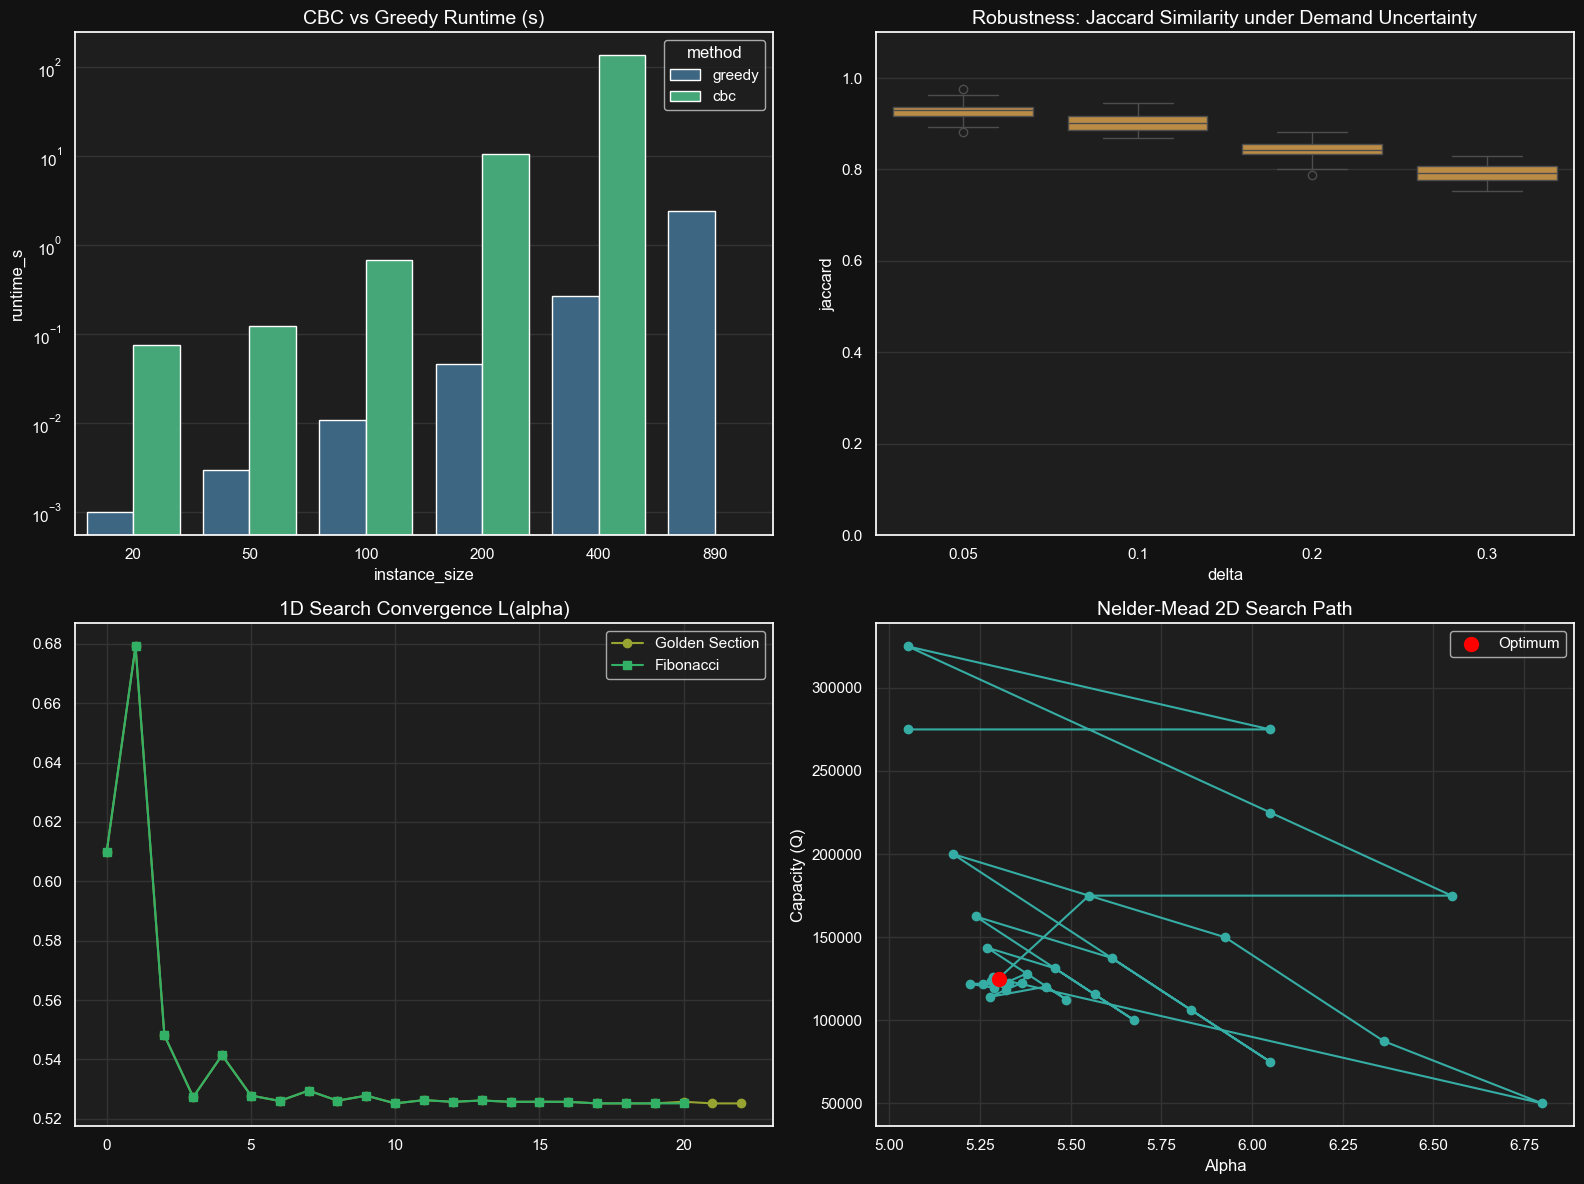

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. CBC vs Greedy (Runtime)
sns.barplot(data=df_cbc_greedy, x="instance_size", y="runtime_s", hue="method", ax=axes[0,0], palette="viridis")
axes[0,0].set_title("CBC vs Greedy Runtime (s)", color='white', fontsize=14)
axes[0,0].set_yscale('log')

# 2. Robustness (Jaccard vs Delta)
sns.boxplot(data=df_rob, x="delta", y="jaccard", ax=axes[0,1], color=colors[1])
axes[0,1].set_title("Robustness: Jaccard Similarity under Demand Uncertainty", color='white', fontsize=14)
axes[0,1].set_ylim(0, 1.1)

# 3. 1D Convergence
iters_g = [x['iter'] for x in res_golden['history']]
L_g = [x['L'] for x in res_golden['history']]
iters_f = [x['iter'] for x in res_fib['history']]
L_f = [x['L'] for x in res_fib['history']]
axes[1,0].plot(iters_g, L_g, marker='o', label='Golden Section', color=colors[2])
axes[1,0].plot(iters_f, L_f, marker='s', label='Fibonacci', color=colors[3])
axes[1,0].set_title("1D Search Convergence L(alpha)", color='white', fontsize=14)
axes[1,0].legend()

# 4. 2D Search Path (Nelder Mead)
alphas = [x['alpha'] for x in res_nm['history']]
Qs = [x['Q'] for x in res_nm['history']]
axes[1,1].plot(alphas, Qs, marker='o', linestyle='-', color=colors[4])
axes[1,1].scatter(alphas[-1], Qs[-1], color='red', s=100, label='Optimum', zorder=5)
axes[1,1].set_title("Nelder-Mead 2D Search Path", color='white', fontsize=14)
axes[1,1].set_xlabel("Alpha")
axes[1,1].set_ylabel("Capacity (Q)")
axes[1,1].legend()

plt.tight_layout()
# Saved under a notebook_ prefix so it does NOT clash with generate_outputs.py's results_summary.png
plt.savefig(f"{OUTPUTS_DIR}/figures/notebook_results_summary.png", facecolor='#121212')
plt.show()

## 4. Pareto Analysis

Sweeping $\alpha$ traces the trade-off between the **number of open DCs** and the **total service cost**.
The knee of this curve (minimum normalized loss $L=\hat N+\hat S$) identifies the chosen operating point:
fewer DCs → lower opening cost but longer, more expensive deliveries, and vice-versa.

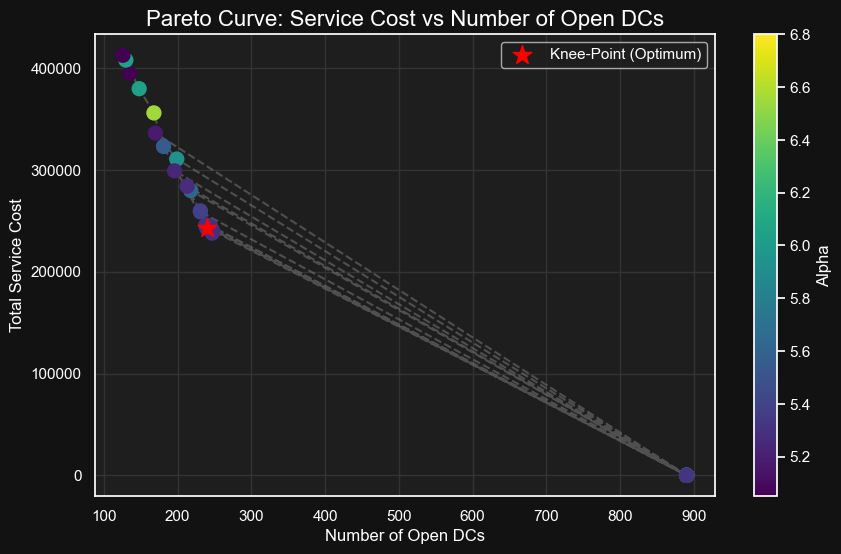

In [4]:
alphas_eval = [x['alpha'] for x in res_nm['history']]
n_dcs = [x['n_open'] for x in res_nm['history']]
s_costs = [x['service_cost'] for x in res_nm['history']]

plt.figure(figsize=(10, 6))
plt.scatter(n_dcs, s_costs, c=alphas_eval, cmap='viridis', s=100, zorder=3)
plt.plot(n_dcs, s_costs, linestyle='--', color='gray', alpha=0.5)
plt.colorbar(label='Alpha')
opt_idx = np.argmin([x['L'] for x in res_nm['history']])
opt_n_open = res_nm['history'][opt_idx]['n_open']
opt_service_cost = res_nm['history'][opt_idx]['service_cost']
plt.scatter(opt_n_open, opt_service_cost, color='red', s=200, marker='*', label='Knee-Point (Optimum)', zorder=4)

plt.title("Pareto Curve: Service Cost vs Number of Open DCs", color='white', fontsize=16)
plt.xlabel("Number of Open DCs")
plt.ylabel("Total Service Cost")
plt.legend()
# Saved under a notebook_ prefix so it does NOT clash with generate_outputs.py's pareto_curve.png
plt.savefig(f"{OUTPUTS_DIR}/figures/notebook_pareto_curve.png", facecolor='#121212')
plt.show()

## 5. Interactive Dashboard

Adjustable hyperparameters (sliders): **$\alpha$** (opening-cost scaling), **$Q$** (DC capacity),
**traffic scenario** (blended / peak / off-peak), **demand uncertainty $\delta$**, and the candidate-DC
**subset size**. Each change re-solves the CFLP with the greedy heuristic and redraws the Folium map
(open DCs + their assigned neighborhoods) along with summary statistics — letting one explore how the
optimal network shifts under different cost, capacity, traffic and uncertainty assumptions.

> **IMPORTANT NOTE:** To view and interact with the live map dashboard, run the final code cell below.

In [5]:
out = widgets.Output()
from IPython.display import clear_output

def render_dashboard(*args):
    alpha = alpha_slider.value
    Q = q_slider.value
    scenario = scenario_dropdown.value
    delta = delta_slider.value
    subset_size = subset_slider.value
    
    # 1. Prepare data based on widgets
    w_sim = w[:subset_size].copy()
    if delta > 0.0:
        np.random.seed(42)
        eps = np.random.uniform(1.0 - delta, 1.0 + delta, size=subset_size)
        w_sim = w_sim * eps
        
    t_sim = t_blended[:subset_size, :subset_size]
    if scenario == 'Peak': t_sim = t_peak[:subset_size, :subset_size]
    elif scenario == 'Off-Peak': t_sim = t_offpeak[:subset_size, :subset_size]
    
    r_sim = r[:subset_size]
    
    # 2. Run greedy solver
    res = solve_cflp(w_sim, t_sim, r_sim, alpha, Q, Q0=100_000.0, method="greedy")
    
    # 3. Create Map
    m = folium.Map(location=[41.05, 28.97], zoom_start=11, tiles="CartoDB dark_matter")
    
    open_dcs = np.where(res['y'] > 0.5)[0]
    assignment = res['z']
    
    palette = sns.color_palette("husl", len(open_dcs)).as_hex()
    
    for idx, j in enumerate(open_dcs):
        folium.Marker(
            location=[df_n.iloc[j]['lat'], df_n.iloc[j]['lon']],
            popup=f"DC: {df_n.iloc[j]['name']}",
            icon=folium.Icon(color="red", icon="info-sign")
        ).add_to(m)
        
        assigned_hoods = np.where(assignment[:, j] > 0.5)[0]
        for i in assigned_hoods:
            if i != j:
                folium.PolyLine(
                    locations=[[df_n.iloc[i]['lat'], df_n.iloc[i]['lon']], 
                               [df_n.iloc[j]['lat'], df_n.iloc[j]['lon']]],
                    color=palette[idx],
                    weight=1,
                    opacity=0.6
                ).add_to(m)
                folium.CircleMarker(
                    location=[df_n.iloc[i]['lat'], df_n.iloc[i]['lon']],
                    radius=2,
                    color=palette[idx],
                    fill=True
                ).add_to(m)
    
    # Save map
    m.save(f"{OUTPUTS_DIR}/maps/notebook_preview_{scenario.lower().replace('-', '')}.html")
    
    # 4. Show summary stats
    html = f"""
    <div style='color: white; background: #1e1e1e; padding: 15px; border-radius: 8px;'>
        <h3>Simulation Results</h3>
        <ul>
            <li><b>Open DCs:</b> {len(open_dcs)}</li>
            <li><b>Total Cost:</b> {res['objective']:,.2f} TL</li>
            <li><b>Scenario:</b> {scenario}</li>
            <li><b>Alpha:</b> {alpha} | <b>Q:</b> {Q:,.0f}</li>
        </ul>
    </div>
    """
    with out:
        clear_output(wait=True)
        display(HTML(html))
        display(m)

# Widgets setup
# Default operating point = chosen optimum from the 1D parameter search
# (Golden+Fibonacci agree at α≈1.37, Q fixed at 200,000). See search_comparison.csv.
ALPHA_OPT = 1.37
Q_OPT = 200_000.0
style = {'description_width': 'initial'}
alpha_slider = widgets.FloatSlider(value=ALPHA_OPT, min=0.1, max=10.0, step=0.1, description='Alpha (Cost scaling):', style=style, layout=widgets.Layout(width='500px'))
q_slider = widgets.FloatSlider(value=Q_OPT, min=50000, max=500000, step=10000, description='Q (Capacity):', style=style, layout=widgets.Layout(width='500px'))
scenario_dropdown = widgets.Dropdown(options=['Blended', 'Peak', 'Off-Peak'], value='Blended', description='Traffic Scenario:', style=style)
delta_slider = widgets.FloatSlider(value=0.0, min=0.0, max=0.30, step=0.05, description='Demand Delta (Robustness):', style=style, layout=widgets.Layout(width='500px'))
subset_slider = widgets.IntSlider(value=100, min=10, max=890, step=10, description='Candidate DCs subset:', style=style, layout=widgets.Layout(width='500px'))

alpha_slider.observe(render_dashboard, names='value')
q_slider.observe(render_dashboard, names='value')
scenario_dropdown.observe(render_dashboard, names='value')
delta_slider.observe(render_dashboard, names='value')
subset_slider.observe(render_dashboard, names='value')

# Initialize the first map
render_dashboard()

controls = widgets.VBox([alpha_slider, q_slider, scenario_dropdown, delta_slider, subset_slider])
display(widgets.HBox([controls]))
display(out)

Output()